# MRI Frequency Explorer

Interactive notebook for loading DICOM MRI images and exploring their frequency (k-space) content via 2D FFT-based filtering.

## 1. Environment Setup and Library Imports

In [ ]:
%pip install pydicom numpy matplotlib ipywidgets ipympl scipy --quiet --break-system-packages

error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try brew install
    xyz, where xyz is the package you are trying to
    install.
    
    If you wish to install a Python library that isn't in Homebrew,
    use a virtual environment:
    
    python3 -m venv path/to/venv
    source path/to/venv/bin/activate
    python3 -m pip install xyz
    
    If you wish to install a Python application that isn't in Homebrew,
    it may be easiest to use 'pipx install xyz', which will manage a
    virtual environment for you. You can install pipx with
    
    brew install pipx
    
    You may restore the old behavior of pip by passing
    the '--break-system-packages' flag to pip, or by adding
    'break-system-packages = true' to your pip.conf file. The latter
    will permanently disable this error.
    
    If you disable this error, we STRONGLY recommend that you additionally
    pass the '--user' flag to pip, or set 

In [4]:
import warnings
warnings.filterwarnings("ignore")

import pathlib
import json
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import pydicom
import ipywidgets as widgets
from ipywidgets import interact, interactive, fixed, HBox, VBox, Output
from IPython.display import display, clear_output
from scipy import ndimage

# Try interactive widget backend; fall back to inline if not available
try:
    get_ipython().run_line_magic("matplotlib", "widget")
    _backend = "widget"
except Exception:
    get_ipython().run_line_magic("matplotlib", "inline")
    _backend = "inline"

plt.rcParams.update({
    "figure.facecolor": "#0e0e0e",
    "axes.facecolor": "#0e0e0e",
    "axes.edgecolor": "#555",
    "text.color": "#ddd",
    "xtick.color": "#aaa",
    "ytick.color": "#aaa",
    "axes.titlecolor": "#eee",
    "image.cmap": "gray",
    "figure.dpi": 100,
})

print(f"Matplotlib backend: {_backend}")
print("All libraries loaded successfully.")

Matplotlib backend: inline
All libraries loaded successfully.


## 2. Load DICOM Files from the `MRI/` Folder

In [5]:
MRI_ROOT = pathlib.Path("MRI")

def load_dicom_series(root: pathlib.Path) -> list[pydicom.Dataset]:
    """Recursively find all DICOM files under root, return sorted by slice position."""
    candidates = [p for p in root.rglob("*") if p.is_file() and not p.suffix.lower() in {".inf", ".htm", ".txt", ".cab"}]
    datasets = []
    for path in candidates:
        try:
            ds = pydicom.dcmread(str(path), stop_before_pixels=False)
            if hasattr(ds, "pixel_array"):
                datasets.append(ds)
        except Exception:
            pass
    # Sort by ImagePositionPatient z-coordinate or InstanceNumber fallback
    def sort_key(ds):
        try:
            return float(ds.ImagePositionPatient[2])
        except Exception:
            try:
                return int(ds.InstanceNumber)
            except Exception:
                return 0
    datasets.sort(key=sort_key)
    return datasets


all_series: list[pydicom.Dataset] = load_dicom_series(MRI_ROOT)
print(f"Loaded {len(all_series)} DICOM slices.")
if all_series:
    ds0 = all_series[0]
    print(f"  Modality    : {getattr(ds0, 'Modality', 'N/A')}")
    print(f"  Patient     : {getattr(ds0, 'PatientName', 'N/A')}")
    print(f"  Image size  : {ds0.pixel_array.shape}")
    print(f"  Pixel type  : {ds0.pixel_array.dtype}")

Loaded 1134 DICOM slices.
  Modality    : CT
  Patient     : EDUARDO TODT
  Image size  : (512, 512)
  Pixel type  : int16


## 3. Construct 3D Slice Stack

In [7]:
def apply_modality_lut(ds: pydicom.Dataset) -> np.ndarray:
    """Apply RescaleSlope / RescaleIntercept if present, return float32 array."""
    arr = ds.pixel_array.astype(np.float32)
    slope = float(getattr(ds, "RescaleSlope", 1))
    intercept = float(getattr(ds, "RescaleIntercept", 0))
    return arr * slope + intercept


# Group by shape and keep the largest consistent group
from collections import Counter
shape_counts = Counter(ds.pixel_array.shape for ds in all_series)
dominant_shape = shape_counts.most_common(1)[0][0]
filtered_series = [ds for ds in all_series if ds.pixel_array.shape == dominant_shape]
print(f"Using {len(filtered_series)} slices with shape {dominant_shape} (dropped {len(all_series) - len(filtered_series)} mismatched)")

volume: np.ndarray = np.stack([apply_modality_lut(ds) for ds in filtered_series], axis=0)
print(f"Volume shape : {volume.shape}  (slices × rows × cols)")
print(f"Intensity range : [{volume.min():.1f}, {volume.max():.1f}]")

try:
    pixel_spacing = [float(v) for v in filtered_series[0].PixelSpacing]
except Exception:
    pixel_spacing = [1.0, 1.0]
print(f"Pixel spacing : {pixel_spacing} mm")

Using 1057 slices with shape (512, 512) (dropped 77 mismatched)
Volume shape : (1057, 512, 512)  (slices × rows × cols)
Intensity range : [-3024.0, 2720.0]
Pixel spacing : [0.261719, 0.261719] mm


## 4. Display MRI Slice with Intensity Normalization

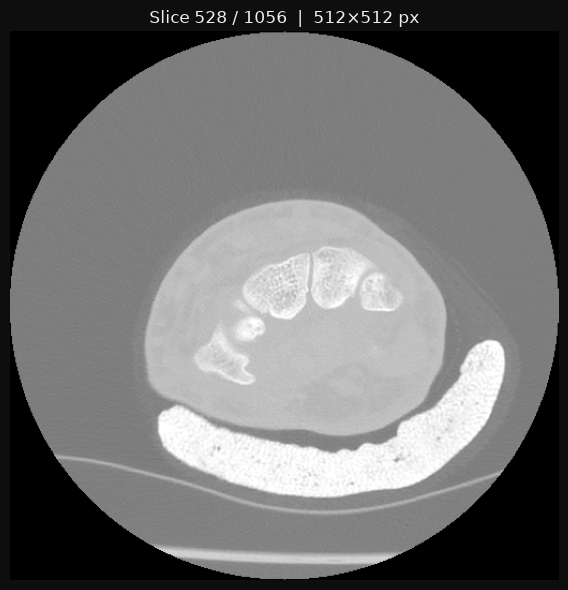

Modality        : CT
Series Desc     : VOLUME PM
Window Center   : 50
Window Width    : 300


In [8]:
def normalize(arr: np.ndarray, low_pct: float = 1.0, high_pct: float = 99.0) -> np.ndarray:
    lo, hi = np.percentile(arr, [low_pct, high_pct])
    return np.clip((arr - lo) / (hi - lo + 1e-8), 0, 1)


DEFAULT_SLICE = len(volume) // 2
slice_img = volume[DEFAULT_SLICE]

fig, ax = plt.subplots(1, 1, figsize=(6, 6))
ax.imshow(normalize(slice_img), cmap="gray", origin="upper")
ax.set_title(f"Slice {DEFAULT_SLICE} / {len(volume) - 1}  |  {slice_img.shape[1]}×{slice_img.shape[0]} px")
ax.axis("off")
plt.tight_layout()
plt.show()

ds_meta = all_series[DEFAULT_SLICE]
print(f"Modality        : {getattr(ds_meta, 'Modality', 'N/A')}")
print(f"Series Desc     : {getattr(ds_meta, 'SeriesDescription', 'N/A')}")
print(f"Window Center   : {getattr(ds_meta, 'WindowCenter', 'N/A')}")
print(f"Window Width    : {getattr(ds_meta, 'WindowWidth', 'N/A')}")

## 5. Compute and Visualize Frequency Domain (2D FFT / k-space)

The 2D FFT maps each spatial frequency component.  
- **Low frequencies** (center of the spectrum) → large-scale contrast & overall brightness.  
- **High frequencies** (periphery) → edges, fine detail, and noise.

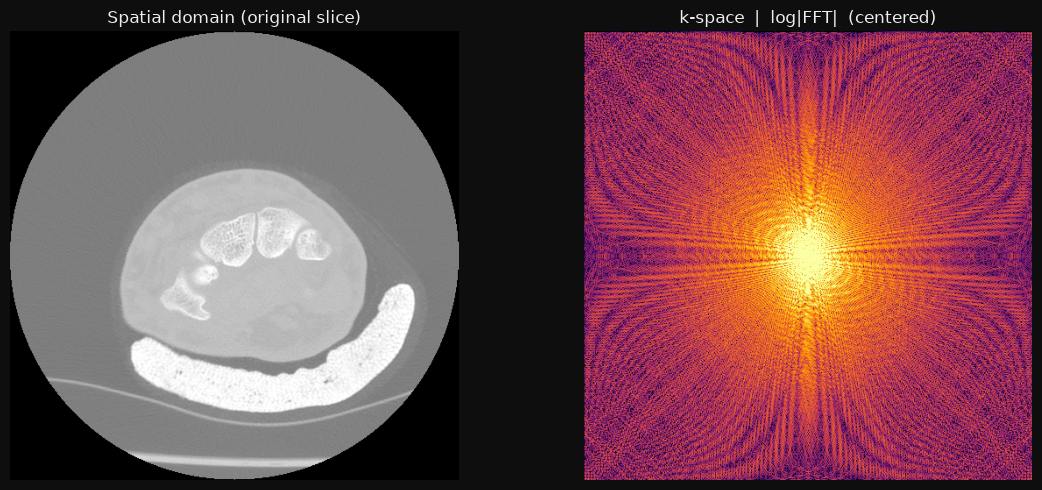

In [9]:
def compute_kspace(img: np.ndarray) -> np.ndarray:
    """Return centered 2D FFT of img."""
    return np.fft.fftshift(np.fft.fft2(img.astype(np.float64)))


kspace = compute_kspace(slice_img)
log_magnitude = np.log1p(np.abs(kspace))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(normalize(slice_img), cmap="gray")
axes[0].set_title("Spatial domain (original slice)")
axes[0].axis("off")

axes[1].imshow(normalize(log_magnitude), cmap="inferno")
axes[1].set_title("k-space  |  log|FFT|  (centered)")
axes[1].axis("off")

plt.tight_layout()
plt.show()

## 6. Frequency Filter Masks (Low-pass / High-pass / Band-pass)

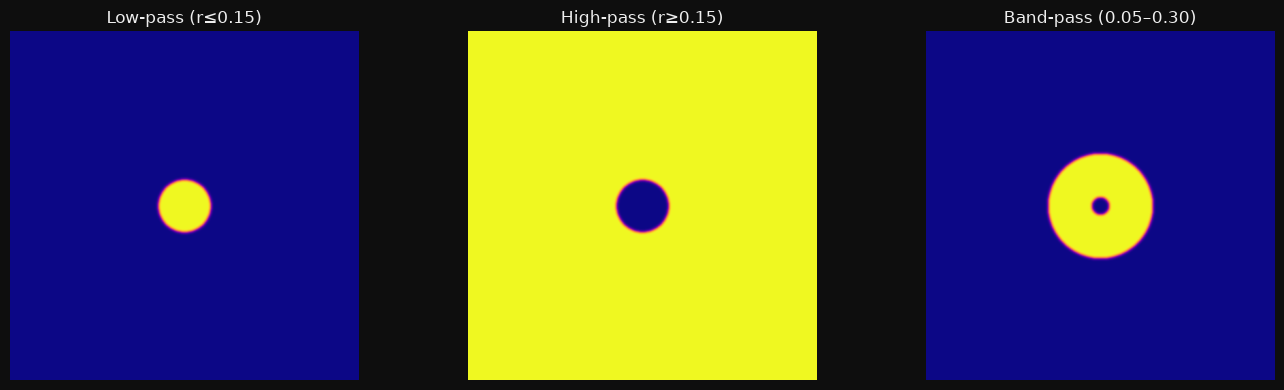

In [10]:
def radial_distance_map(rows: int, cols: int) -> np.ndarray:
    """Normalised radial distance map [0, 1] centred at DC component."""
    cy, cx = rows / 2, cols / 2
    y = (np.arange(rows) - cy) / cy
    x = (np.arange(cols) - cx) / cx
    xx, yy = np.meshgrid(x, y)
    return np.sqrt(xx**2 + yy**2)


def make_mask(rows: int, cols: int, kind: str, r_low: float, r_high: float) -> np.ndarray:
    """Return a float32 mask in the range [0, 1].

    kind  : 'lowpass' | 'highpass' | 'bandpass'
    r_low : inner cutoff (0..1 of Nyquist radius)
    r_high: outer cutoff (0..1 of Nyquist radius)
    """
    D = radial_distance_map(rows, cols)
    if kind == "lowpass":
        mask = (D <= r_high).astype(np.float32)
    elif kind == "highpass":
        mask = (D >= r_low).astype(np.float32)
    else:  # bandpass
        mask = ((D >= r_low) & (D <= r_high)).astype(np.float32)
    # Soften mask edges with a small Gaussian blur to reduce ringing
    mask = ndimage.gaussian_filter(mask, sigma=2.0)
    return mask


# Preview masks side by side
rows, cols = slice_img.shape
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
titles = ["Low-pass (r≤0.15)", "High-pass (r≥0.15)", "Band-pass (0.05–0.30)"]
masks = [
    make_mask(rows, cols, "lowpass",  0.0,  0.15),
    make_mask(rows, cols, "highpass", 0.15, 1.0),
    make_mask(rows, cols, "bandpass", 0.05, 0.30),
]
for ax, m, t in zip(axes, masks, titles):
    ax.imshow(m, cmap="plasma", vmin=0, vmax=1)
    ax.set_title(t)
    ax.axis("off")
plt.tight_layout()
plt.show()

## 7. Reconstruct Image from Filtered Frequencies

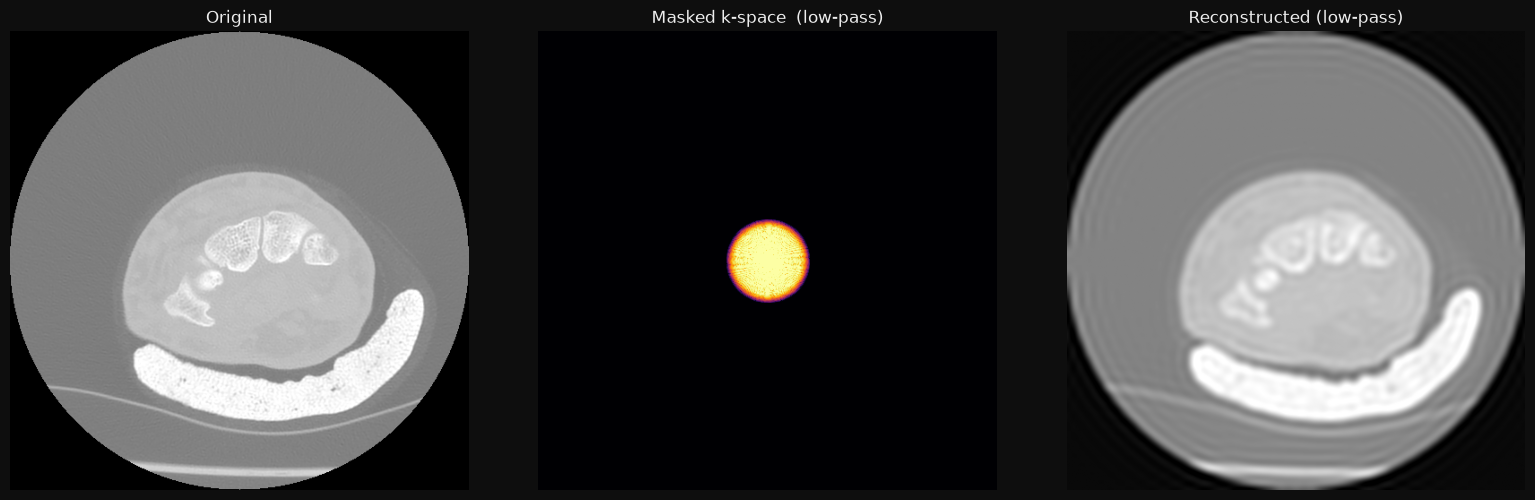

In [11]:
def reconstruct(img: np.ndarray, mask: np.ndarray) -> np.ndarray:
    """Apply mask in k-space and inverse FFT back to spatial domain."""
    kspace_filtered = compute_kspace(img) * mask
    reconstructed = np.fft.ifft2(np.fft.ifftshift(kspace_filtered)).real
    return reconstructed.astype(np.float32)


# Static demo with a low-pass filter
demo_mask = make_mask(rows, cols, "lowpass", 0.0, 0.15)
demo_recon = reconstruct(slice_img, demo_mask)
masked_kspace_log = np.log1p(np.abs(compute_kspace(slice_img) * demo_mask))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
axes[0].imshow(normalize(slice_img), cmap="gray")
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(normalize(masked_kspace_log), cmap="inferno")
axes[1].set_title("Masked k-space  (low-pass)")
axes[1].axis("off")

axes[2].imshow(normalize(demo_recon), cmap="gray")
axes[2].set_title("Reconstructed (low-pass)")
axes[2].axis("off")

plt.tight_layout()
plt.show()

## 8. Interactive UI — Real-Time Frequency Tuning

Use the sliders below to:
- Select the **slice** in the volume
- Choose the **filter type** (low-pass, high-pass, band-pass)
- Adjust **inner / outer cutoff radii** (as fraction of Nyquist, 0 → 1)

In [12]:
n_slices = len(volume)

# --- widgets ---
w_slice = widgets.IntSlider(
    value=n_slices // 2, min=0, max=n_slices - 1, step=1,
    description="Slice:", continuous_update=False,
    layout=widgets.Layout(width="500px"),
    style={"description_width": "60px"},
)
w_filter = widgets.ToggleButtons(
    options=["lowpass", "highpass", "bandpass"],
    value="lowpass",
    description="Filter:",
    style={"description_width": "60px", "button_width": "100px"},
)
w_r_low = widgets.FloatSlider(
    value=0.0, min=0.0, max=1.0, step=0.01,
    description="r inner:", continuous_update=False,
    layout=widgets.Layout(width="500px"),
    style={"description_width": "60px"},
)
w_r_high = widgets.FloatSlider(
    value=0.15, min=0.0, max=1.0, step=0.01,
    description="r outer:", continuous_update=False,
    layout=widgets.Layout(width="500px"),
    style={"description_width": "60px"},
)

out = Output()


def update(change=None):
    slice_idx = w_slice.value
    kind = w_filter.value
    r_low = w_r_low.value
    r_high = w_r_high.value

    img = volume[slice_idx]
    r, c = img.shape
    mask = make_mask(r, c, kind, r_low, r_high)
    recon = reconstruct(img, mask)
    masked_log = np.log1p(np.abs(compute_kspace(img) * mask))

    with out:
        clear_output(wait=True)
        fig, axes = plt.subplots(1, 3, figsize=(16, 5))
        fig.suptitle(
            f"Slice {slice_idx}/{n_slices - 1}  |  {kind}  |  r_inner={r_low:.2f}  r_outer={r_high:.2f}",
            color="#eee", fontsize=12,
        )
        axes[0].imshow(normalize(img), cmap="gray")
        axes[0].set_title("Original")
        axes[0].axis("off")

        axes[1].imshow(normalize(masked_log), cmap="inferno")
        axes[1].set_title("Masked k-space")
        axes[1].axis("off")

        axes[2].imshow(normalize(recon), cmap="gray")
        axes[2].set_title("Reconstructed")
        axes[2].axis("off")

        plt.tight_layout()
        plt.show()


for w in [w_slice, w_filter, w_r_low, w_r_high]:
    w.observe(update, names="value")

controls = VBox([
    HBox([w_slice]),
    HBox([w_filter]),
    HBox([w_r_low, w_r_high]),
])

display(controls, out)
update()  # initial render

Output()

## 9. Export Filtered Results and Comparison Figures

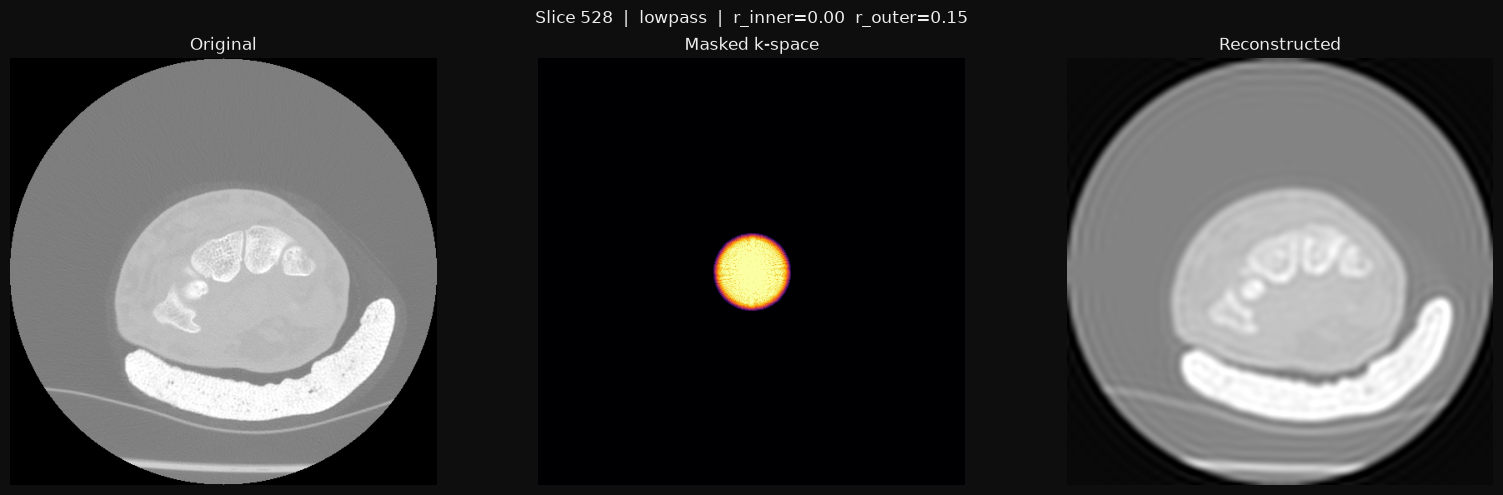

Exported to /Users/pedro.tricossi/src/UFPR/visaoComputacional/mri_exports


In [13]:
OUTPUT_DIR = pathlib.Path("mri_exports")
OUTPUT_DIR.mkdir(exist_ok=True)

# Read current widget state
export_slice_idx = w_slice.value
export_kind      = w_filter.value
export_r_low     = w_r_low.value
export_r_high    = w_r_high.value

export_img   = volume[export_slice_idx]
r, c         = export_img.shape
export_mask  = make_mask(r, c, export_kind, export_r_low, export_r_high)
export_recon = reconstruct(export_img, export_mask)

# Save NumPy arrays
np.save(OUTPUT_DIR / "original_slice.npy", export_img)
np.save(OUTPUT_DIR / "reconstructed_slice.npy", export_recon)
np.save(OUTPUT_DIR / "filter_mask.npy", export_mask)

# Save comparison figure
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(
    f"Slice {export_slice_idx}  |  {export_kind}  |  r_inner={export_r_low:.2f}  r_outer={export_r_high:.2f}",
    color="#eee",
)
axes[0].imshow(normalize(export_img),   cmap="gray");  axes[0].set_title("Original");      axes[0].axis("off")
axes[1].imshow(normalize(np.log1p(np.abs(compute_kspace(export_img) * export_mask))), cmap="inferno")
axes[1].set_title("Masked k-space"); axes[1].axis("off")
axes[2].imshow(normalize(export_recon), cmap="gray");  axes[2].set_title("Reconstructed"); axes[2].axis("off")
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "comparison.png", dpi=150, bbox_inches="tight")
plt.show()

# Save filter parameters
params = {
    "slice_index": export_slice_idx,
    "filter_type": export_kind,
    "r_inner":     export_r_low,
    "r_outer":     export_r_high,
}
with open(OUTPUT_DIR / "filter_params.json", "w") as f:
    json.dump(params, f, indent=2)

print(f"Exported to {OUTPUT_DIR.resolve()}")